In [128]:
# Input statements
import matplotlib.pyplot as plt
import numpy as np
import os
import shlex
import subprocess

In [86]:
# Special imports
from tempfile import TemporaryDirectory

Template variables:
- `list_of_points`
- `variables`
- `problem`

In [87]:
def dakota_evaluate(dakota_in, **kwargs):

    # Replace keywords
    for key, val in kwargs.items():
        dakota_in = dakota_in.replace("{" + key + "}", val)

    
    with TemporaryDirectory() as tmp:

        # Write input file
        with open(os.path.join(tmp, "dakota.in"), "w") as io:
            io.write(dakota_in)

        # Execute Dakota
        command = shlex.split("dakota dakota.in")
        subprocess.run(command, cwd=tmp, stdout = subprocess.DEVNULL)

        # Extract results
        return np.genfromtxt(os.path.join(tmp, "output.txt"), comments="%")

In [125]:
def steady_state_diffusion_1d(points, level=0, template="dakota.in.template"):

    # Read template file
    dakota_template_file = template
    with open(dakota_template_file, "r") as io:
        dakota_in = io.read()

    # Format list of points
    list_of_points = "\n"
    for point in points:
        list_of_points += " ".join(map(str, point)) + "\n"

    # Format variables
    _, num_terms = points.shape
    variables = f"uniform_uncertain = {num_terms} \n\
	  lower_bounds      =  {num_terms}*-1. \n\
	  upper_bounds      =  {num_terms}* 1. \n\
    discrete_state_set \n\
	  integer = 1 \n\
	    set_values = {2 * 2**level} \n\
	    descriptors = 'mesh_size'"
    
    # Evaluate dakota
    return dakota_evaluate(dakota_in, list_of_points=list_of_points, variables=variables, problem="'steady_state_diffusion_1d'")[:, -1]


In [137]:
# Evaluate points
num_points = 10000
num_dims = 9
num_levels = 6

points = 2 * np.random.rand(num_points, num_dims) - 1
solutions = [steady_state_diffusion_1d(points, level) for level in range(num_levels)]

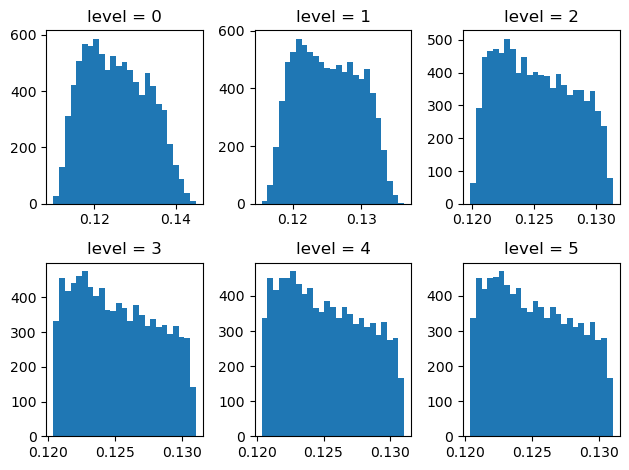

In [138]:
# Plot histograms
_, axes = plt.subplots(2, 3)
for idx, ax in enumerate(axes.flatten()):
    ax.hist(solutions[idx], bins=25)
    ax.set_title(f"level = {idx}")
plt.tight_layout()